# Denoising plots

In [1]:
# Imports
from pathlib import Path
from tqdm.notebook import tqdm
import numpy as np
import zarr
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"

In [2]:
# Define data and save paths, and general options
save_root = Path("../data/figures/paper/denoising")
save_root.mkdir(exist_ok=True, parents=True)

data_root = Path("../data/processed/denoised/Au_01-vol_01.zarr")
spacing_dir = "50-10-10"

In [3]:
# Load data
raw = zarr.open_array(data_root / f"raw/{spacing_dir}")
denoised = zarr.open_array(data_root / f"denoised/{spacing_dir}")

## Comparison plots

### Distribution of residuals

In [4]:
# Calculate histogram of residuals across the entire volume
hist = np.zeros(511)
for i in tqdm(range(raw.shape[0])):
    residuals = raw[i].astype(np.int16) - denoised[i].astype(np.int16) + 255
    hist += np.bincount((residuals).ravel(), minlength=511)

  0%|          | 0/701 [00:00<?, ?it/s]

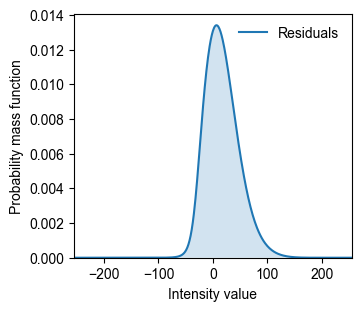

In [5]:
fig, ax = plt.subplots(layout="constrained", figsize=(3.5, 3))

alpha = 0.2

hits_norm = hist / hist.sum()
x = np.arange(511) - 255
ax.plot(x, hits_norm, label="Residuals")
ax.fill_between(x, hits_norm, 0, alpha=alpha)
ax.set(
    xlim=(-255, 255),
    ylim=(0, hits_norm.max() * 1.05),
    xlabel="Intensity value",
    ylabel="Probability mass function",
)
ax.legend(frameon=False)
fig.savefig(
    save_root / "Denoising-n2v-residuals.pdf", bbox_inches="tight", pad_inches=0.01
)

### Detail comparison

In [6]:
# Select image and crops
img_idx = 452
np_top = (3400, 3400)
mito_top = (3000, 4100)
width = 200

np_slice = (
    img_idx,
    slice(np_top[0], np_top[0] + width),
    slice(np_top[1], np_top[1] + width),
)
mito_slice = (
    img_idx,
    slice(mito_top[0], mito_top[0] + width),
    slice(mito_top[1], mito_top[1] + width),
)

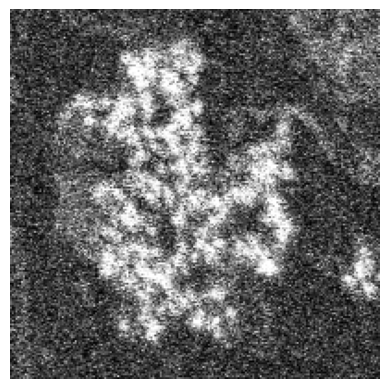

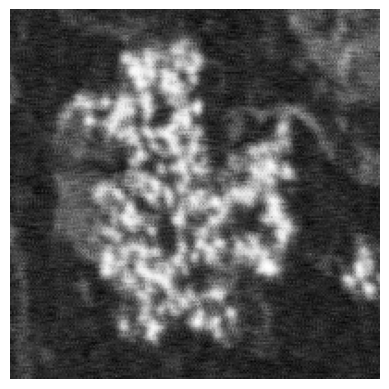

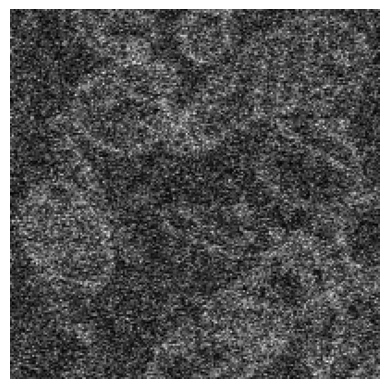

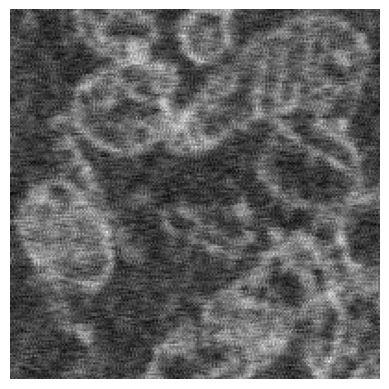

In [7]:
crops = {"np": np_slice, "mito": mito_slice}

for target, crop in crops.items():
    fig, ax = plt.subplots()
    ax.imshow(raw[crop], cmap="gray")
    ax.set_axis_off()
    fig.savefig(
        save_root / f"Denoising-{target}-detail-raw.pdf",
        bbox_inches="tight",
        pad_inches=0.0,
    )

    fig, ax = plt.subplots()
    ax.imshow(denoised[crop], cmap="gray")
    ax.set_axis_off()
    fig.savefig(
        save_root / f"Denoising-{target}-detail-denoised.pdf",
        bbox_inches="tight",
        pad_inches=0.0,
    )